# PS-S5E12: CatBoost

This notebook tackles the [**Playground Series – Season 5, Episode 12: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s5e12), a competition focused on aiding medical diagnosis: predict if a patient will be diagnosed with diabetes.  The goal is to develop a model that can accurately predict whether a patient will be diagnosed with diabetes, based on a set of medical and demographic features.

## Introduction

**CatBoost** distinguishes itself with its native handling of categorical features, eliminating the need for extensive manual encoding (like One-Hot) often required by other gradient boosting libraries. It utilizes "Ordered Boosting" to combat target leakage and employs symmetric decision trees, which often leads to more robust generalization and faster inference speeds. This model is particularly effective when dealing with datasets containing a mix of numerical physiological markers and categorical demographic data without requiring complex preprocessing.
The notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S5E12: EDA**](https://www.kaggle.com/code/stephentarter/ps-s5e12-eda).

## Install Needed Packages

In [1]:
%load_ext autoreload
%autoreload 2
    
import os
import gc
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import catboost as cb
from catboost import Pool
import optuna
from optuna.samplers import TPESampler # Import this
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from diabetes_preprocessing import FeatureFactory
from model_visualizer import ModelVisualizer
from experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'diagnosed_diabetes'

# Show GPU be utilized in training
USE_GPU = False

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_training_dataset()

TRAINING DATASET

   id  age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   0   31                             1                                  45   
1   1   50                             2                                  73   
2   2   32                             3                                 158   
3   3   54                             3                                  77   
4   4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day    bmi  \
0       7.700                6.800                      6.100 33.400   
1       5.700                6.500                      5.800 23.800   
2       8.500                7.400                      9.100 24.100   
3       4.600                7.000                      9.200 26.600   
4       5.700                6.200                      5.100 28.800   

   waist_to_hip_ratio  systolic_bp  diastolic_bp  heart_rate  \
0   

## Read and Examine the Test Dataset

In [4]:
test_df = helper.read_test_dataset()

TEST DATASET

       id  age  alcohol_consumption_per_week  \
0  700000   45                             4   
1  700001   35                             1   
2  700002   45                             1   
3  700003   55                             2   
4  700004   77                             2   

   physical_activity_minutes_per_week  diet_score  sleep_hours_per_day  \
0                                 100       4.300                6.800   
1                                  87       3.500                4.600   
2                                  61       7.600                6.800   
3                                  81       7.300                7.300   
4                                  29       7.300                7.600   

   screen_time_hours_per_day    bmi  waist_to_hip_ratio  systolic_bp  \
0                      6.200 25.500               0.840          123   
1                      9.000 28.600               0.880          120   
2                      7.000 28.500 

## Feature Engineering

In [5]:
# Define which strategies to use for the CatBoost model here:
fe_strategies = [
    'drop_id',
    'ordinal_encoding',
    'medical_metrics',
    'clinical_indices',
    'interactions',
    'ratios',
    'log',
    'binning',
    'cohort_deviations',
    'clustering'
]

In [6]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 25
New Feature Count: 44
   age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   31                             1                                  45   
1   50                             2                                  73   
2   32                             3                                 158   
3   54                             3                                  77   
4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day    bmi  \
0       7.700                6.800                      6.100 33.400   
1       5.700                6.500                      5.800 23.800   
2       8.500                7.400                      9.100 24.100   
3       4.600                7.000                      9.200 26.600   
4       5.700                6.200                      5.100 28.800   

   waist_to_hip_ratio  sys

In [7]:
def get_cat_features(df, cardinality_threshold=10):
    # Start with explicit string/category columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Add integer columns that act as categories
    # Iterate through numerical columns
    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    for col in num_cols:
        # If a number has very few unique values, treat it as categorical
        if df[col].nunique() <= cardinality_threshold:
            cat_cols.append(col)
            
    return cat_cols

cat_features = get_cat_features(X)
print(f'Detected Categoricals: {cat_features}')

print('Sanitizing categorical features...')

# Fill NaNs with a generic placeholder (optional, but safer)
# and convert to string to ensure no floats remain.
for col in cat_features:
    # Ensure the column is in the dataframe (sanity check)
    if col in X.columns:
        # Check if it's float or object with mixed types
        # We force it to string. This converts 2.0 -> "2.0" and NaN -> "nan"
        X[col] = X[col].astype(str)
        
        # We must apply the exact same transformation to X_test
        X_test[col] = X_test[col].astype(str)
            
print('Categoricals converted to strings. Floats eliminated.')

Detected Categoricals: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'alcohol_consumption_per_week', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'education_level_ord', 'income_level_ord', 'bmi_class', 'bp_class', 'cluster_label', 'age_decile']
Sanitizing categorical features...
Categoricals converted to strings. Floats eliminated.


## Recursive Feature Elimination and Optuna Training

This section optionally runs an Optuna trial to determine the best set of hyperscaling parameters.  If training isn't requested, a set of hyperparameters derived from an earlier run is used instead.

If Optuna Tuning was run, Recursive Feature Elimination (RFE) is performed.  This works by training the model, identifying the weakest feature, deleting it, and then re-training. It repeats this process until it finds the exact subset of features that gives the highest Cross-Validation score.

In [8]:
from catboost import CatBoostClassifier, Pool, EShapCalcType, EFeaturesSelectionAlgorithm
from sklearn.model_selection import train_test_split

n_jobs = 1 if USE_GPU else -1

if PERFORM_RFE:    
    print('Running Recursive Feature Elimination (this will take a few minutes)...')
    
    # Define the model
    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='AUC',
        cat_features=cat_features, # Pass your list of names or indices
        verbose=200,
        random_state=seed,
        early_stopping_rounds=50
    )
    
    # CREATE A SPLIT FOR FEATURE SELECTION
    # We need a validation set so CatBoost knows which features generalize well
    X_fs_train, X_fs_val, y_fs_train, y_fs_val = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    # Create CatBoost Pools (required for feature selection)
    train_pool = Pool(X_fs_train, y_fs_train, cat_features=cat_features)
    val_pool = Pool(X_fs_val, y_fs_val, cat_features=cat_features)   
    
    # Run Native Feature Selection
    summary = model.select_features(
        train_pool,
        eval_set=val_pool,
        features_for_select=train_pool.get_feature_names(), # Pass the list of column names
        num_features_to_select=25,                          # How many features you want to keep
        steps=1,                                            # How many elimination rounds
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByShapValues,
        shap_calc_type=EShapCalcType.Regular,
        train_final_model=False,                            # We just want the list, we'll retrain later
        plot=False
    )
    
    # View Selected Features
    # Save the selected features for the next step
    optimal_cols = summary['selected_features_names']
    print('Selected Features:', optimal_cols)
else:
    print('Using columns from an earlier RFE as optimal features.')
    optimal_cols = pd.Index([
        'age',
        'physical_activity_minutes_per_week',
        'diet_score',
        'screen_time_hours_per_day',
        'bmi',
        'waist_to_hip_ratio',
        'systolic_bp',
        'diastolic_bp',
        'heart_rate',
        'cholesterol_total',
        'hdl_cholesterol',
        'ldl_cholesterol',
        'triglycerides',
        'family_history_diabetes',
        'cardiovascular_history', 
        'non_hdl_cholesterol',
        'vai_proxy',
        'lap_proxy',
        'bmi_class',
        'age_bmi_interaction',
        'sedentary_ratio',
        'cholesterol_risk_ratio', 
        'triglycerides_log',
        'screen_time_log',
        'bmi_cohort_mean'
    ])
    
print('\nOptimal Features:')
print(optimal_cols)

Running Recursive Feature Elimination (this will take a few minutes)...
Step #1 out of 1
0:	test: 0.6742742	best: 0.6742742 (0)	total: 648ms	remaining: 10m 47s
200:	test: 0.7065695	best: 0.7065695 (200)	total: 1m 50s	remaining: 7m 20s
400:	test: 0.7155721	best: 0.7155721 (400)	total: 3m 48s	remaining: 5m 41s
600:	test: 0.7189217	best: 0.7189217 (600)	total: 5m 53s	remaining: 3m 55s
800:	test: 0.7205436	best: 0.7205461 (799)	total: 7m 46s	remaining: 1m 55s
999:	test: 0.7215473	best: 0.7215473 (999)	total: 9m 43s	remaining: 0us

bestTest = 0.7215472863
bestIteration = 999

Feature #22 eliminated
Feature #36 eliminated
Feature #26 eliminated
Feature #16 eliminated
Feature #24 eliminated
Feature #17 eliminated
Feature #15 eliminated
Feature #19 eliminated
Feature #40 eliminated
Feature #4 eliminated
Feature #37 eliminated
Feature #20 eliminated
Feature #18 eliminated
Feature #27 eliminated
Feature #41 eliminated
Feature #25 eliminated
Feature #1 eliminated
Feature #43 eliminated
Feature #3

### Addressing Data Distribution Shift: Synthetic vs. Original Data

[Recent community findings](https://www.kaggle.com/code/masayakawamata/s5e12-xgb-bridging-the-cv-lb-gap) have identified a significant distribution shift within the training dataset. Specifically, the data appears to be split into two distinct segments:
*   **Synthetic Data:** Records from index 0 to 678,259 generated by a deep learning model.
*   **Original Data:** Records from index 678,260 to the end, representing real-world patient data.

Crucially, the **Test Set** (Public Leaderboard) closely follows the distribution of the **Original Data**.

**Impact on Training Strategy**

To bridge the gap between Cross-Validation (CV) scores and the Public Leaderboard (LB), we cannot simply use a standard K-Fold split across the entire dataset. Doing so would validate the model primarily on synthetic patterns, which may not generalize to the real-world test data.

The Solution: "Bridging" Validation Scheme

We have modified the training pipeline to implement a custom validation strategy:
1.  **Split the Train Data:** We explicitly separate the dataset into Synthetic and Original subsets based on the index 678,260.
2.  **Original-Only Validation:** The K-Fold splitter is applied **only** to the Original Data indices.
3.  **Hybrid Training Sets:** For every fold `k`:
    *   **Validation Set:** The $k$-th fold of the Original Data.
    *   **Training Set:** All Synthetic Data + the remaining `(k-1)` folds of the Original Data.

This ensures that our CV metric reflects performance on real data (like the LB), while still leveraging the massive volume of synthetic data for regularization and learning complex feature interactions.

**Additional Adjustments:**
*   **Sample Weights:** We apply higher sample weights (2.0) to the Original Data rows during training to force the model to prioritize real patterns over synthetic artifacts.
*   **Categorical Encoding:** We ensure consistent OrdinalEncoding and type casting to category for all object columns (e.g., Gender, Ethnicity) to fully utilize LightGBM's native categorical handling capabilities.

In [9]:
# A split in the data has been described here: https://www.kaggle.com/code/masayakawamata/s5e12-xgb-bridging-the-cv-lb-gap
# This is the index identified above; we'll use it to split the data
ORIGINAL_START_INDEX = 678260

# Filter the datasets to contain just the optimal features
X_rfe = X[optimal_cols]

# Determine the cat_features for the new dataset
cat_features = get_cat_features(X_rfe)

# Ensure optimal_cols is a standard list for filtering
# (Handling cases where it might be a pandas Index or numpy array)
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols
    
def objective(trial):
    # Explicit garbage collection at start of trial
    gc.collect()
    
    # Suggest critical categorical parameters first to control logic flow
    bootstrap_type = 'Bernoulli'   # trial.suggest_categorical('bootstrap_type', ['Bernoulli', 'MVS'])
    grow_policy = trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide'])
    
    param = {
        # Core Structure
        'iterations': 8000,              # Equiv to n_estimators
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        
        # STRUCTURAL PARAMS
        'grow_policy': grow_policy,
        'depth': trial.suggest_int('depth', 4, 10),
        
        # REGULARIZATION
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-1, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-1, 10.0, log=True),

        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 3.0),
        
        # BOOTSTRAPPING
        'bootstrap_type': bootstrap_type,
    
        # CATEGORICALS
        # Important: Dictates when to switch to One-Hot vs Target Encoding
        'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 10),
        
        # GENERAL
        'subsample': trial.suggest_float('subsample', 0.5, 0.95),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
        
        # Boilerplate
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'GPU' if USE_GPU else 'CPU',
        'random_seed': seed,
        'early_stopping_rounds': 200,
        'thread_count': n_jobs,
        'verbose': False,
        'allow_writing_files': False,        # Stop it from spamming drive with log folders
    }

    if grow_policy == 'Lossguide':
        param['max_leaves'] = trial.suggest_int('max_leaves', 16, 64)
        
    if param['task_type'] == 'GPU':
        param['metric_period'] = 100

    # Separate Synthetic and Original Indices
    synthetic_mask = training_df.index < ORIGINAL_START_INDEX
    original_mask = training_df.index >= ORIGINAL_START_INDEX
    
    # Indices for synthetic data (Always used in Training)
    synth_indices = training_df[synthetic_mask].index.to_numpy()
    
    # Indices for original data (Used for CV splitting)
    orig_indices = training_df[original_mask].index.to_numpy()
    orig_targets = y[original_mask] # Needed for stratification
    
    # Initialize CV on Original Data ONLY
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    
    oof_preds = np.zeros(len(y)) # Keep full size for compatibility, but only fill original
    test_preds = np.zeros(len(test_df))

    # Custom Loop
    # We split ONLY the original indices
    for fold, (train_idx_orig_relative, val_idx_orig_relative) in enumerate(skf.split(orig_indices, orig_targets)):
        
        # Map relative indices back to global dataframe indices
        global_train_orig_idx = orig_indices[train_idx_orig_relative]
        global_val_orig_idx = orig_indices[val_idx_orig_relative]
        
        # CONSTRUCT TRAINING SET: All Synthetic + (K-1) Original Folds
        final_train_idx = np.concatenate([synth_indices, global_train_orig_idx])
        
        # CONSTRUCT VALIDATION SET: Just the K-th Original Fold
        final_val_idx = global_val_orig_idx
        
        # Fill fold for training and validation using the indices we just constructed.
        X_train_fold = training_df.iloc[final_train_idx]
        y_train_fold = y.iloc[final_train_idx]
        
        X_val_fold = training_df.iloc[final_val_idx]
        y_val_fold = y.iloc[final_val_idx]
        
        # Feature Engineering (Per fold to prevent leakage)
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
        
        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        # Create Sample Weights. Initialize weights as 1.0
        train_weights = np.ones(len(X_train_fold))
        
        # Identify indices that belong to the Original Dataset within the current training fold
        num_synth = len(synth_indices)
        
        # Everything after num_synth is Original data. Assign higher weight (e.g., 2.0 or 3.0)
        train_weights[num_synth:] = 2.0
        
        # Restrict to optimal column set
        if cols_to_keep is not None:
            final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
            if not final_cols:
                # If this ever happens in tuning, you'd rather fail fast
                raise RuntimeError("No overlap between optimal_cols and fold feature columns.")
            X_train_trans = X_train_trans[final_cols]
            X_val_trans   = X_val_trans[final_cols]
        
        # Identify categorical columns for CatBoost
        cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()
        
        # Ensure categorical columns are strings (CatBoost-friendly)
        if cat_cols:
            for c in cat_cols:
                X_train_trans[c] = X_train_trans[c].astype(str)
                X_val_trans[c]   = X_val_trans[c].astype(str)

        # Create CatBoost Pools and immediately delete the pandas DataFrames to free RAM
        train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_cols, weight=train_weights)
        val_pool = Pool(X_val_trans, y_val_fold, cat_features=cat_cols)

        # Model with the current trial's params
        model = cb.CatBoostClassifier(**param, cat_features=cat_cols)
        
        model.fit(
            train_pool,
            eval_set=[val_pool],
            verbose=False,
            use_best_model=True,
        )
        
        # Store OOF predictions (Only for the validation rows)
        val_probs = model.predict_proba(X_val_trans)[:, 1]
        oof_preds[final_val_idx] = val_probs
        
        # Score this fold
        fold_auc = roc_auc_score(y_val_fold, val_probs)

    # Final Metric Calculation
    # ONLY calculate score on the original data indices
    final_valid_mask = oof_preds != 0 
    original_data_auc = roc_auc_score(y[original_mask], oof_preds[original_mask])
    
    return np.mean(original_data_auc)

In [10]:
if PERFORM_OPTUNA_TUNING:
    # Run Optimization
    sampler = TPESampler(seed=seed)
    
    study = optuna.create_study(
        study_name='cb_diabetes_prediction_optuna', 
        direction='maximize',
        sampler=sampler
    )
    study.optimize(objective, n_trials=40, n_jobs=1, gc_after_trial=True, show_progress_bar=True)

    print('Best Params:', study.best_params)
    print('Best AUC:', study.best_value)

    best_params = study.best_params
else:
    # Values from earlier tuning
    best_params = {
        'grow_policy': 'Lossguide',
        'learning_rate': 0.021548495022782603,
        'depth': 8,
        'l2_leaf_reg': 5.457296004538218,
        'random_strength': 0.6497444068426594,
        'scale_pos_weight': 1.0017466334645033,
        'one_hot_max_size': 5,
        'subsample': 0.7616606176479994,
        'min_data_in_leaf': 1,
        'max_leaves': 23
    }

[I 2025-12-29 11:25:37,153] A new study created in memory with name: cb_diabetes_prediction_optuna


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-12-29 11:29:45,554] Trial 0 finished with value: 0.6975309851420499 and parameters: {'grow_policy': 'Lossguide', 'learning_rate': 0.047622943216448436, 'depth': 6, 'l2_leaf_reg': 3.3836013395362015, 'random_strength': 9.872404659829796, 'scale_pos_weight': 2.329597616109332, 'one_hot_max_size': 6, 'subsample': 0.7201865835605259, 'min_data_in_leaf': 60, 'max_leaves': 41}. Best is trial 0 with value: 0.6975309851420499.
[I 2025-12-29 11:32:19,905] Trial 1 finished with value: 0.6961294995091123 and parameters: {'grow_policy': 'Depthwise', 'learning_rate': 0.053418516337357974, 'depth': 8, 'l2_leaf_reg': 0.7697341143641978, 'random_strength': 1.0640027734625037, 'scale_pos_weight': 1.4934309118180107, 'one_hot_max_size': 8, 'subsample': 0.5155246523332255, 'min_data_in_leaf': 58}. Best is trial 0 with value: 0.6975309851420499.
[I 2025-12-29 11:44:30,855] Trial 2 finished with value: 0.6969199911067895 and parameters: {'grow_policy': 'SymmetricTree', 'learning_rate': 0.0074087687

## Model Training

In [11]:
# Cross-Validation Training Loop

cb_tuned_params = {
    **best_params,
    'iterations': 8000,
    'eval_metric': 'AUC',
    'task_type': 'CPU',  # We must use CPU if we want both training and validation numbers
    'random_state': seed,
    'verbose': 200,
    'bootstrap_type': 'Bernoulli',
    'allow_writing_files': False,        # Stop it from spamming drive with log folders
    'early_stopping_rounds': 200,
}

print('Final CatBoost CV Training with OOF / Test predictions')
print('======================================================')
print('Parameters used for training:')
print(cb_tuned_params)

# Ensure optimal_cols is a standard list for filtering
# (Handling cases where it might be a pandas Index or numpy array)
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

# Separate Synthetic and Original Indices
synthetic_mask = training_df.index < ORIGINAL_START_INDEX
original_mask = training_df.index >= ORIGINAL_START_INDEX

# Indices for synthetic data (Always used in Training)
synth_indices = training_df[synthetic_mask].index.to_numpy()

# Indices for original data (Used for CV splitting)
orig_indices = training_df[original_mask].index.to_numpy()
orig_targets = y[original_mask] # Needed for stratification

# Initialize CV on Original Data ONLY
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

print(f"Training on {len(synth_indices)} synthetic rows + Original Data Folds")
print(f"Validating strictly on {len(orig_indices)} original rows")
print(' ')

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_preds = np.zeros(len(y)) # Keep full size for compatibility, but only fill original
test_preds = np.zeros(len(test_df))

# Custom Loop
# We split ONLY the original indices
for fold, (train_idx_orig_relative, val_idx_orig_relative) in enumerate(skf.split(orig_indices, orig_targets)):

    print(f"Starting processing of fold {fold+1}")

    # Map relative indices back to global dataframe indices
    global_train_orig_idx = orig_indices[train_idx_orig_relative]
    global_val_orig_idx = orig_indices[val_idx_orig_relative]
    
    # CONSTRUCT TRAINING SET: All Synthetic + (K-1) Original Folds
    final_train_idx = np.concatenate([synth_indices, global_train_orig_idx])
    
    # CONSTRUCT VALIDATION SET: Just the K-th Original Fold
    final_val_idx = global_val_orig_idx
    
    # Fill fold for training and validation using the indices we just constructed.
    X_train_fold = training_df.iloc[final_train_idx]
    y_train_fold = y.iloc[final_train_idx]
    
    X_val_fold = training_df.iloc[final_val_idx]
    y_val_fold = y.iloc[final_val_idx]
    
    # Feature Engineering (Per fold to prevent leakage)
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    
    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)

    # Create Sample Weights. Initialize weights as 1.0
    train_weights = np.ones(len(X_train_fold))
    
    # Identify indices that belong to the Original Dataset within the current training fold
    num_synth = len(synth_indices)
    
    # Everything after num_synth is Original data. Assign higher weight (e.g., 2.0 or 3.0)
    train_weights[num_synth:] = 2.0

    # Restrict to optimal column set
    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError("No overlap between optimal_cols and fold feature columns.")
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]
        X_test_trans  = X_test_trans[final_cols]

    cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()

    # Ensure categorical columns are strings (CatBoost-friendly)
    if cat_cols:
        for c in cat_cols:
            X_train_trans[c] = X_train_trans[c].astype(str)
            X_val_trans[c]   = X_val_trans[c].astype(str)
            X_test_trans[c]   = X_test_trans[c].astype(str)

    # Create CatBoost Pools and immediately delete the pandas DataFrames to free RAM
    train_pool = Pool(X_train_trans, y_train_fold, cat_features=cat_cols, weight=train_weights)
    val_pool = Pool(X_val_trans, y_val_fold, cat_features=cat_cols)
    test_pool = Pool(X_test_trans, cat_features=cat_cols)

    # Transform Datakage)
    # Note: We are fitting the preprocessor every fold. 
    model = cb.CatBoostClassifier(**cb_tuned_params, cat_features=cat_cols)
    
    # Train Model
    model.fit(
        train_pool,
        # CatBoost automatically tracks metrics on the training set (learn)
        # We pass validation set to track generalization
        eval_set=[train_pool, val_pool],
        verbose=100,
        early_stopping_rounds=50,
        use_best_model=True
    )
    
    # Store Results
    eval_results.append(model.get_evals_result()) # Different method name than XGB!
    models.append(model)    

    # Store OOF predictions (Only for the validation rows)
    val_probs = model.predict_proba(val_pool)[:, 1]
    oof_preds[final_val_idx] = val_probs
    
    # Score this fold
    fold_auc = roc_auc_score(val_pool.get_label(), val_probs)
    print(f"Fold {fold+1} Original-Data AUC: {fold_auc:.5f} (best_iteration={model.get_best_iteration()})")
    
    # Predict Test Set (Accumulate for averaging)
    test_probs = model.predict_proba(test_pool)[:, 1]
    test_preds += test_probs / n_folds

# Final Metric Calculation
# ONLY calculate score on the original data indices
final_valid_mask = oof_preds != 0 # 
original_data_auc = roc_auc_score(y[original_mask], oof_preds[original_mask])
print(f"\nOverall CV AUC (Original Data Only): {original_data_auc:.5f}")

Final CatBoost CV Training with OOF / Test predictions
Parameters used for training:
{'grow_policy': 'Lossguide', 'learning_rate': 0.021548495022782603, 'depth': 8, 'l2_leaf_reg': 5.457296004538218, 'random_strength': 0.6497444068426594, 'scale_pos_weight': 1.0017466334645033, 'one_hot_max_size': 5, 'subsample': 0.7616606176479994, 'min_data_in_leaf': 1, 'max_leaves': 23, 'iterations': 8000, 'eval_metric': 'AUC', 'task_type': 'CPU', 'random_state': 10301, 'verbose': 200, 'bootstrap_type': 'Bernoulli', 'allow_writing_files': False, 'early_stopping_rounds': 200}
Training on 678260 synthetic rows + Original Data Folds
Validating strictly on 21740 original rows
 
Starting processing of fold 1
0:	test: 0.6818573	test1: 0.6693827	best: 0.6693827 (0)	total: 241ms	remaining: 32m 10s
100:	test: 0.7038334	test1: 0.6870000	best: 0.6870000 (100)	total: 30.9s	remaining: 40m 20s
200:	test: 0.7117683	test1: 0.6920708	best: 0.6920708 (200)	total: 57.9s	remaining: 37m 28s
300:	test: 0.7163379	test1: 0.

## Visualize the Quality of Training

It is standard practice to visualize Learning Curves (to spot overfitting/underfitting) and the ROC Curve (to check classification performance).

### Learning Curves (Train vs. Validation AUC)

**Definition**  
This graph plots the model's performance (AUC) on the y-axis against the number of boosting rounds (iterations) on the x-axis. It displays two lines:
*   **Blue (Train):** How well the model learned the data it has already seen.
*   **Red (Validation):** How well the model generalizes to new data it hasn't seen.

**Interpretation**  
This graph is fairly easy to interpret, and is a powerful indicator of how the model is likely to perform on new data.
*   **Ideal:** Both lines go up steeply and plateau. The Blue line is slightly higher than the Red line, but the gap is stable.
*   **Overfitting:** The Blue line keeps going up (approaching 1.0), but the Red line flattens out early or starts dropping. The "gap" between them widens significantly.
*   **Underfitting:** Both lines flatten out very early at a low score. The model is too simple to learn the patterns.

**Actions for Overfitting**  
If the Training score is 0.95 but the validation score is 0.72, the  are overfitting.
1.  **Restrict Depth:** Reduce `max_depth` (e.g., from 6 to 3 or 4). This forces the model to learn simpler, more general rules.
2.  **Add Randomness:** Lower `subsample` and `colsample_bytree` (e.g., to 0.6). This prevents the model from relying too heavily on specific rows or features.
3.  **Increase Regularization:** Increase `reg_alpha` (L1) or `reg_lambda` (L2). This penalizes the model for becoming too complex.
4.  **Increase `min_child_weight`:** This prevents the tree from creating leaves that only apply to a tiny handful of patients (noise).

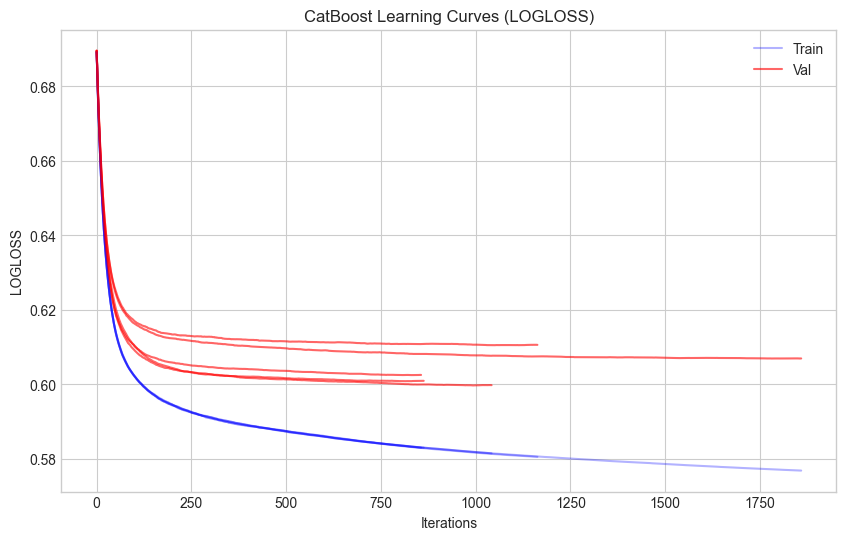

In [12]:
mviz = ModelVisualizer(model_name='CatBoost')

mviz.plot_learning_curves(eval_results, metric='Logloss')

### Feature Importance (Gain)

This chart ranks features by how much they improved the model's accuracy (reduced the loss function) whenever they were used in a split.

**Interpretation**  
*   **High Gain:** These are the "Signal" features. The model relies on them heavily.
*   **Low/Zero Gain:** These features were rarely useful. The model mostly ignored them.

**What if engineered features aren't at the top?**  
*   **Don't Panic:** It's okay if raw features like Glucose or BMI are still top. They are strong predictors!
*   **Check Correlations:** If BMI is #1 and your engineered BMI\_Ratio is #50, they might be highly correlated, and the model just chose the simpler one. This is fine.
*   **Re-evaluate:** If an engineered feature is at the very bottom (0 importance), it failed. The hypothesis behind it (e.g., "Age \* Height") likely has no biological relevance.

**What to do with Low Performing Features**  
*   **Zero Importance:** **Drop them.** They add computational cost and noise without adding value.
*   **Low Importance:**  
    *   **Try Dropping:** Sometimes removing "noise" features helps the model focus on the signal (increases score).
  
    *   **Combine Them:** If SkinThickness is weak on its own, try creating an interaction like Insulin / SkinThickness. Sometimes two weak features make one strong feature.

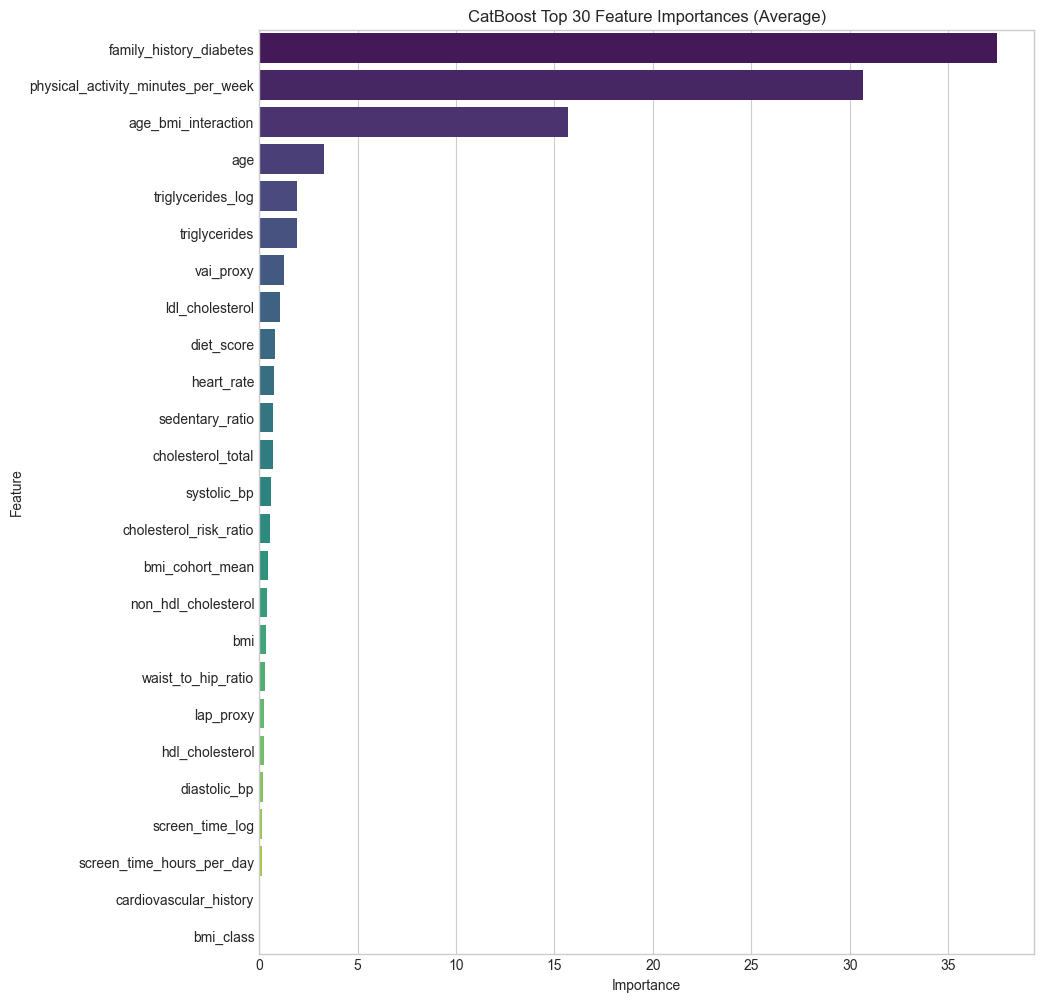

In [13]:
mviz.plot_feature_importance(models, show_values=True)

### ROC Curve (Receiver Operating Characteristic)

A plot of the **True Positive Rate** (Sensitivity) vs. the **False Positive Rate** (1 - Specificity) at every possible probability threshold (0% to 100%).

**Interpretation**  
*   **Top-Left Corner:** The perfect model. It catches 100% of diabetes cases with 0 false alarms.
*   **Diagonal Line:** Random guessing (AUC = 0.5).
*   **The Curve:** Shows the trade-off. To catch more diabetes cases (move up), we inevitably accept more false alarms (move right).
    

**What else can ROC be used for?**  
*   **Threshold Tuning:** The model outputs a probability (e.g., 0.35). Is that a "Yes" or a "No"?
    *   If this is a **Pre-Screening App** (high sensitivity needed), we pick a point high on the Y-axis (e.g., threshold 0.2), accepting that we'll flag some healthy people.
    *   If this is for **Surgery** (high precision needed), we pick a point far left on the X-axis (e.g., threshold 0.8), ensuring we only operate when very certain.
*   **Model Comparison:** In the upcoming "Model Blending/Stacking" notebook, we can plot the curves for XGBoost, CatBoost, and LightGBM on one graph. If the curves cross, one model might be better for high-sensitivity tasks while the other is better for high-precision tasks, even if their AUC is similar.

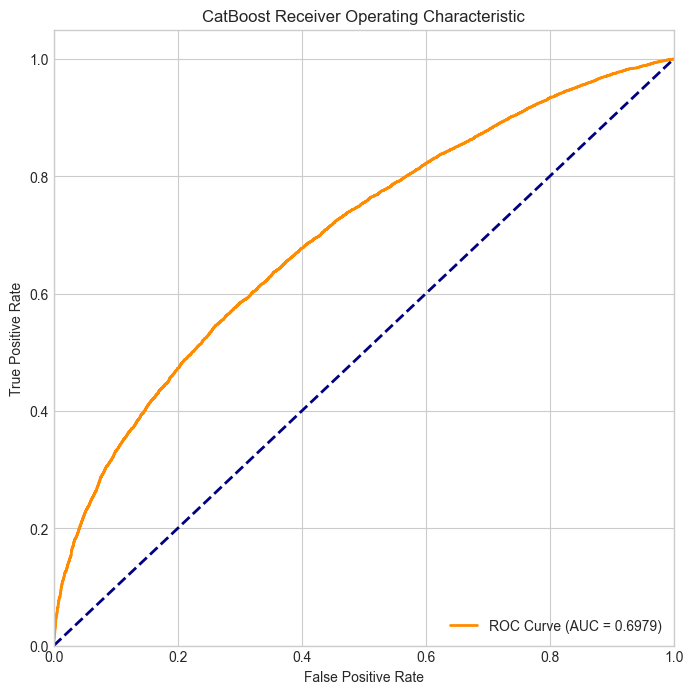

In [14]:
mviz.plot_roc_curve(y[original_mask], oof_preds[original_mask])

## Prepare Submission

In [15]:
submission_df = helper.read_sample_submission_dataset()
submission_df[TARGET] = test_preds

print('SAMPLE SUBMISSION')
print('=================')

print(submission_df.head(10))

SAMPLE SUBMISSION
       id  diagnosed_diabetes
0  700000               0.510
1  700001               0.686
2  700002               0.764
3  700003               0.408
4  700004               0.903
5  700005               0.639
6  700006               0.737
7  700007               0.917
8  700008               0.578
9  700009               0.818


In [16]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Predictions

The OOF and test predictions are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the predictions of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [17]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({'id': training_df.index, 'pred_cb': oof_preds, 'target': y})
oof_df.to_csv(f'{output_dir}/cb_oof_preds.csv', index=False)

test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_cb': test_preds})
test_pred_df.to_csv(f'{output_dir}/cb_test_preds.csv', index=False)

print(f'Saved for Blending: {output_dir}/cb_oof_preds.csv, {output_dir}/cb_test_preds.csv')

Saved for Blending: predictions/cb_oof_preds.csv, predictions/cb_test_preds.csv
